In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# LOAD DATASET
def load_data(file_path="Industrial_Innovation_Tracker_Merged.csv"):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully\n")
    print(df.head())
    return df


In [ ]:
#EDA + Correlation
def perform_eda(df):

    print("\nDataset Info:")
    print(df.info())

    print("\nSummary Statistics:")
    print(df.describe())

    print("\nMissing Values:")
    print(df.isnull().sum())

    numeric_df = df.select_dtypes(include=['number'])

    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

In [4]:
# PREPARE DATA
def prepare_data(df):
    X = df[["R&D_Expenditure_%GDP", "Researchers_per_Million"]]
    y = df["Patent_Applications"]
    return X, y

In [ ]:
# EVALUATE MODEL(VIF)
def calculate_vif(X):

    X_const = sm.add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_const.values, i + 1)
        for i in range(len(X.columns))
    ]

    print("\nVariance Inflation Factor (VIF):")
    print(vif_data)


In [6]:
# TRAIN MODEL
def train_model_lr(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return model, X_test, y_test, y_pred

In [7]:
#Random Forest Model
def train_model_rf(X, y, n_estimators=200, random_state=42):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return model, X_test, y_test, y_pred

In [ ]:
#Model Evaluation
def evaluate_model(y_test, y_pred):

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print("\nModel Performance:")
    print("R² Score:", round(r2, 3))
    print("RMSE:", round(rmse, 3))

    return r2, rmse

In [9]:
 #PLOT RESULTS (DIFFERENT COLORS)
def plot_results(y_test, y_pred):

    plt.figure()
    plt.scatter(range(len(y_test)), y_test, label="Actual")
    plt.scatter(range(len(y_pred)), y_pred, label="Predicted")

    plt.xlabel("Observations")
    plt.ylabel("Patent Applications")
    plt.title("Actual vs Predicted")
    plt.legend()
    plt.show()

In [ ]:
#SDG-9 Analysis
def sdg9_analysis(model, X, r2):

    print("\nSDG 9 Impact Analysis Report")
    print("--------------------------------")

    if hasattr(model, "coef_"):
        for feature, coef in zip(X.columns, model.coef_):
            print(f"{feature} impact on patents: {round(coef, 3)}")

    elif hasattr(model, "feature_importances_"):
        for feature, imp in zip(X.columns, model.feature_importances_):
            print(f"{feature} importance: {round(imp, 3)}")

    print(f"\nModel explains {round(r2*100,2)}% variation in patent output.")

In [11]:
#Model Comparison
def compare_models(X, y):

    lr_model, X_test, y_test, y_pred_lr = train_model_lr(X, y)
    r2_lr, _ = evaluate_model(y_test, y_pred_lr)

    rf_model, X_test, y_test, y_pred_rf = train_model_rf(X, y)
    r2_rf, _ = evaluate_model(y_test, y_pred_rf)

    print("\nModel Comparison")
    print("----------------")
    print("Linear Regression R²:", round(r2_lr,3))
    print("Random Forest R²:", round(r2_rf,3))

    return lr_model, rf_model

Dataset loaded successfully

  Country Name Country Code  Year  R&D_Expenditure_%GDP  \
0    Australia          AUS  1996               1.66218   
1      Belgium          BEL  1996               1.74299   
2     Bulgaria          BGR  1996               0.41826   
3       Canada          CAN  1996               1.60682   
4  Switzerland          CHE  1996               2.37649   

   Researchers_per_Million  Patent_Applications  
0               3353.70530               1797.0  
1               2477.43906                776.0  
2               1771.85422                316.0  
3               3055.67247               2583.0  
4               3130.03604               2504.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1637 entries, 0 to 1636
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country Name             1637 non-null   object 
 1   Country Code             163

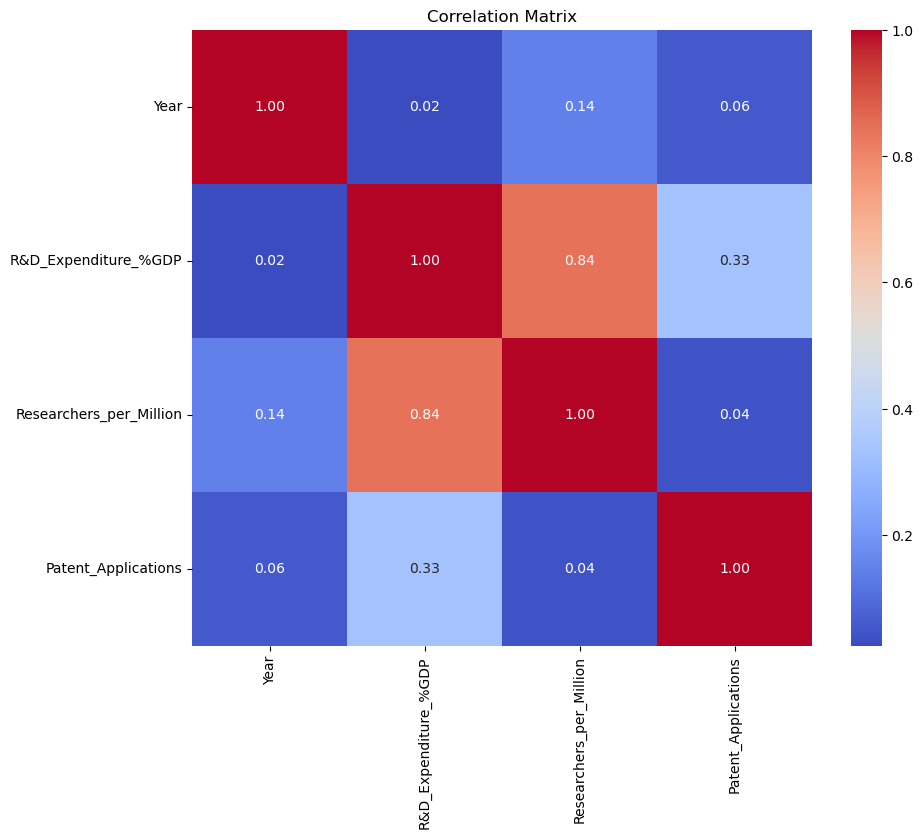


Variance Inflation Factor (VIF):
                   Feature       VIF
0     R&D_Expenditure_%GDP  3.402784
1  Researchers_per_Million  3.402784

Model Performance:
R² Score: 0.775
RMSE: 96740.615


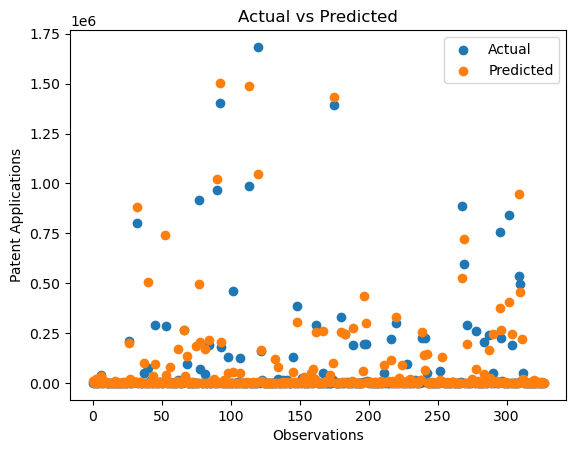


SDG 9 Impact Analysis Report
--------------------------------
R&D_Expenditure_%GDP importance: 0.323
Researchers_per_Million importance: 0.677

Model explains 77.51% variation in patent output.

Model Performance:
R² Score: 0.345
RMSE: 165027.809

Model Performance:
R² Score: 0.775
RMSE: 96740.615

Model Comparison
----------------
Linear Regression R²: 0.345
Random Forest R²: 0.775


(LinearRegression(), RandomForestRegressor(n_estimators=200, random_state=42))

In [12]:
df = load_data("Industrial_Innovation_Tracker_Merged.csv")

perform_eda(df)

X, y = prepare_data(df)

calculate_vif(X)

# Choose model
model, X_test, y_test, y_pred = train_model_rf(X, y)

r2, rmse = evaluate_model(y_test, y_pred)

plot_results(y_test, y_pred)

sdg9_analysis(model, X, r2)

compare_models(X, y)